# Phase II Results — Hybrid CAE + OC-SVM + MEWMA Monitoring

This notebook analyses the frozen Phase II results of the completed monitoring experiment.
Six pre-registered monitoring schemes are evaluated, each calibrated on the Phase I
in-control bank (D3) to a target in-control average run length of $\mathrm{ARL}_0 = 370$:

| Scheme | Monitoring vector | Role |
|---|---|---|
| H(0.05) | $y_t = [s_t, \log \mathrm{SPE}_t]^{\mathsf T}$ | primary hybrid |
| H(0.10) | $y_t = [s_t, \log \mathrm{SPE}_t]^{\mathsf T}$ | hybrid sensitivity |
| H(0.20) | $y_t = [s_t, \log \mathrm{SPE}_t]^{\mathsf T}$ | hybrid sensitivity |
| S(0.05) | $s_t$ only | OC-SVM-score ablation |
| R(0.05) | $\log \mathrm{SPE}_t$ only | reconstruction-error ablation |
| M(0.05) | raw process observations $x_t \in \mathbb{R}^4$ | conventional MEWMA benchmark |

Here $s_t$ is the frozen OC-SVM anomaly score and $\log \mathrm{SPE}_t$ is the log
reconstruction error of the frozen convolutional autoencoder. The number in brackets is
the MEWMA smoothing constant $\lambda$.

The analysis is descriptive only. No model is fitted, no limit is recalibrated and no
simulation is run in this notebook; every table and figure below is computed from the
committed result artifacts. Each thesis figure is also saved under `figures/` as a vector
PDF and a 300-dpi PNG, using the shared style in `thesis_plots.py`.

## 1. Load the committed Phase II results

Three artifacts are read:

- `results/d4_validation_summary.json` — independent in-control validation on D4;
- `results/d5_performance_summary.json` — out-of-control performance on D5;
- `results/run_lengths.npz` — the individual run lengths behind those summaries.

`models/control_limits.json` supplies the frozen Stage 5 control limits $h^{*}$ and the
pre-registered role of each chart.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import to_rgba
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

from thesis_plots import HATCH, NEUTRAL, SCHEME_STYLE, apply_style, save_figure

apply_style()

RESULTS = Path("results")
MODELS = Path("models")
TARGET_ARL0 = 370

d4 = json.loads((RESULTS / "d4_validation_summary.json").read_text())["charts"]
d5 = json.loads((RESULTS / "d5_performance_summary.json").read_text())
d5_cells = d5["cells"]
primary_contrast = d5["primary_contrast"]
interpretation = d5["interpretation"]
limits = json.loads((MODELS / "control_limits.json").read_text())
run_lengths = np.load(RESULTS / "run_lengths.npz")


def label(chart_id, lam):
    """Thesis label for a chart, e.g. 'H(0.05)'."""
    return f"{chart_id}({lam:.2f})"


CHART_ORDER = [label(c["chart_id"], c["lambda"]) for c in limits]
PRIMARY = ["H(0.05)", "M(0.05)"]

deltas = sorted({cell["delta"] for cell in d5_cells})

print(f"D4 chart cells          : {len(d4)}")
print(f"D5 shift magnitudes     : {len(deltas)}  ({deltas[0]} to {deltas[-1]})")
print(f"D5 charts per shift     : {len(d5_cells) // len(deltas)}")
print(f"D5 chart cells in total : {len(d5_cells)}")
print(f"Chart order             : {CHART_ORDER}")

assert len(d4) == 6
assert len(deltas) == 15
assert len(d5_cells) == 90
assert all(len([c for c in d5_cells if c["delta"] == d]) == 6 for d in deltas)

D4 chart cells          : 6
D5 shift magnitudes     : 15  (0.2 to 3.0)
D5 charts per shift     : 6
D5 chart cells in total : 90
Chart order             : ['H(0.05)', 'H(0.10)', 'H(0.20)', 'S(0.05)', 'R(0.05)', 'M(0.05)']


The run lengths are measured in monitoring-opportunity units, and the frozen experiment
records the relationship between a run length and the original process time index:

In [2]:
for key in ("run_length_units", "change_point_tau", "t_signal_relation"):
    print(f"{key}: {interpretation[key]}")

run_length_units: monitoring-opportunity j units
change_point_tau: 1
t_signal_relation: t_signal = RL + 31


The six frozen Stage 5 control limits applied unchanged in Phase II:

In [3]:
limits_table = pd.DataFrame(
    [
        {
            "chart": label(c["chart_id"], c["lambda"]),
            "role": c["role"],
            "dimension": c["dimension"],
            "source": c["source"],
            "h_star": c["h_star"],
            "D3 ARL0": c["achieved_arl0"],
        }
        for c in limits
    ]
)
limits_table

,chart,role,dimension,source,h_star,D3 ARL0
0,H(0.05),primary,2,hybrid_monitoring_vector,111.083017,371.040000
1,H(0.10),hybrid_sensitivity,2,hybrid_monitoring_vector,83.587843,370.540000
2,H(0.20),hybrid_sensitivity,2,hybrid_monitoring_vector,51.430642,372.436667
3,S(0.05),ablation,1,hybrid_monitoring_vector,66.045190,370.630000
4,R(0.05),ablation,1,hybrid_monitoring_vector,71.028396,371.340000
5,M(0.05),benchmark,4,aligned_raw_observations,46.524683,372.426667


## 2. D4 independent in-control validation

D4 is a held-out in-control bank that played no part in estimating the monitoring-vector
moments or in searching the control limits. Running the frozen charts on D4 therefore gives
an independent check of in-control behaviour: it asks whether the limits calibrated on D3
still produce a sensible false-alarm rate on in-control data the calibration never saw.

Because calibration targeted $\mathrm{ARL}_0 = 370$ **on D3**, the D4 values are not
expected to equal 370. Sampling variability in the calibration bank, in the validation bank,
and the finite replication count all contribute. The relevant question is how far the D4
values depart from the target relative to their sampling error, not whether they
reproduce it exactly.

In [4]:
d4_table = pd.DataFrame(
    [
        {
            "chart": label(c["chart_id"], c["lambda"]),
            "lambda": c["lambda"],
            "D3 ARL0 (Stage 5)": c["stage5_d3_achieved_arl0"],
            "D4 ARL0": c["arl0_validation_h"],
            "SDRL": c["sd_run_length"],
            "MRL": c["run_length_median"],
            "SE": c["se_empirical"],
            "censored": c["censor_count"],
            "censor fraction": c["censor_fraction"],
            "deviation from 370": c["deviation_from_target"],
        }
        for c in d4
    ]
).set_index("chart").loc[CHART_ORDER]

d4_table.round(3)

,lambda,D3 ARL0 (Stage 5),D4 ARL0,SDRL,MRL,SE,censored,censor fraction,deviation from 370
chart,,,,,,,,,
H(0.05),0.05,371.040,336.534,328.845,230.5,14.706,0,0.0,-33.466
H(0.10),0.10,370.540,322.332,304.176,226.0,13.603,0,0.0,-47.668
H(0.20),0.20,372.437,315.394,305.896,210.5,13.680,0,0.0,-54.606
S(0.05),0.05,370.630,351.412,333.031,246.5,14.894,0,0.0,-18.588
R(0.05),0.05,371.340,363.444,361.027,253.5,16.146,0,0.0,-6.556
M(0.05),0.05,372.427,403.528,401.284,268.5,17.946,0,0.0,33.528


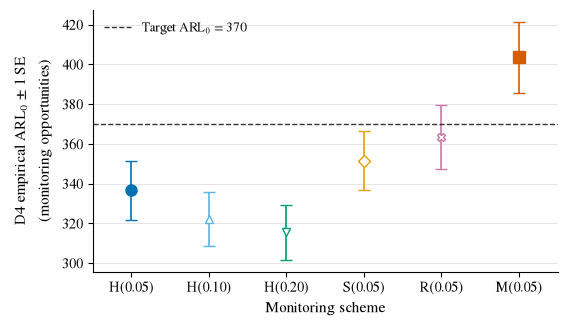

In [5]:
fig, ax = plt.subplots(figsize=(6.0, 3.4))
for position, chart in enumerate(CHART_ORDER):
    style = SCHEME_STYLE[chart]
    ax.errorbar(
        position,
        d4_table.loc[chart, "D4 ARL0"],
        yerr=d4_table.loc[chart, "SE"],
        fmt=style["marker"],
        color=style["color"],
        markerfacecolor=style.get("markerfacecolor", style["color"]),
        markersize=8 if chart in PRIMARY else 6,
        elinewidth=1.2,
        capsize=4,
    )
ax.axhline(TARGET_ARL0, color=NEUTRAL, linestyle="--", linewidth=1,
           label=f"Target ARL$_0$ = {TARGET_ARL0}")
ax.set_xticks(range(len(CHART_ORDER)), CHART_ORDER)
ax.set_xlim(-0.5, len(CHART_ORDER) - 0.5)
ax.set_xlabel("Monitoring scheme")
ax.set_ylabel("D4 empirical ARL$_0$ ± 1 SE\n(monitoring opportunities)")
ax.legend(loc="upper left")
save_figure(fig, "results_d4_arl0_validation")
plt.show()

All six schemes run in-control on D4 with no censored run lengths, so every replication
produced a signal within the available monitoring horizon and none of the reported values is
truncation-limited. The D4 values lie between 315 and 404, within about 15% of the target.
Five of the six schemes validate below the target and the conventional benchmark M(0.05)
above it, with deviations between about 0.4 and 4 standard errors of the D4 estimate: the
three hybrid charts run furthest below target (about $-2.3$, $-3.5$ and $-4.0$ SE for H(0.05),
H(0.10) and H(0.20)), S(0.05) and R(0.05) lie within about 1.3 SE, and M(0.05) is about
1.9 SE above. The calibration therefore broadly carries over to independent in-control data,
with the hybrid charts running somewhat below target (more frequent false alarms than
nominal); the out-of-control results below should be read alongside each chart's realised
D4 $\mathrm{ARL}_0$.

## 3. D5 out-of-control detection performance

D5 contains the out-of-control scenarios. A sustained shift of magnitude $\delta$ is applied
to the latent process from the first retained observation, and the run length is the number
of monitoring opportunities until the chart signals. Fifteen shift magnitudes
$\delta = 0.2, 0.4, \dots, 3.0$ are evaluated for each of the six schemes.

Detection speed is summarised by three run-length statistics:

- **ARL** — mean run length; lower means faster detection;
- **SDRL** — standard deviation of the run length; a measure of detection variability;
- **MRL** — median run length; a robust location summary of the same distribution.

In [6]:
d5_long = pd.DataFrame(
    [
        {
            "chart": label(c["chart_id"], c["lambda"]),
            "delta": c["delta"],
            "ARL": c["arl1_h"],
            "SDRL": c["sd_run_length"],
            "MRL": c["run_length_median"],
            "SE": c["se_empirical"],
            "censored": c["censor_count"],
        }
        for c in d5_cells
    ]
)


def pivot(metric):
    return d5_long.pivot(index="delta", columns="chart", values=metric)[CHART_ORDER]


arl = pivot("ARL")
sdrl = pivot("SDRL")
mrl = pivot("MRL")

print(f"Total censored run lengths across all 90 D5 cells: {d5_long['censored'].sum()}")
arl.round(2)

Total censored run lengths across all 90 D5 cells: 0


chart,H(0.05),H(0.10),H(0.20),S(0.05),R(0.05),M(0.05)
delta,,,,,,
0.2,282.42,278.08,283.55,292.09,336.57,285.59
0.4,229.36,226.27,220.47,235.73,298.41,131.11
0.6,165.25,160.53,155.82,185.82,220.65,59.65
0.8,109.98,105.84,98.97,130.38,160.47,27.67
1.0,78.81,77.71,76.16,103.85,126.07,12.41
1.2,56.13,55.77,53.46,88.60,90.07,7.34
1.4,41.97,40.77,36.44,64.69,69.39,3.11
1.6,30.94,28.42,25.63,61.82,53.01,1.69
1.8,26.07,24.10,22.17,47.67,45.58,1.21


In [7]:
ARL_LABEL = "ARL (monitoring opportunities)\nlower = faster detection"


def format_shift_axis(ax):
    """Tick every simulated shift: labelled ticks at 0.2, 0.6, ..., unlabelled ticks between."""
    ax.set_xticks(deltas[::2])
    ax.set_xticks(deltas[1::2], minor=True)
    ax.xaxis.set_major_formatter("{x:.1f}")
    ax.set_xlim(deltas[0] - 0.1, deltas[-1] + 0.1)
    ax.set_xlabel(r"Shift magnitude $\delta$")


def plot_schemes(ax, table, charts, labels=None):
    """Plot one run-length statistic against delta, one line per scheme.

    Markers sit at the fifteen simulated shifts; the connecting lines only guide the eye
    and are not results at untested shifts.
    """
    labels = labels or {}
    for chart in charts:
        ax.plot(table.index, table[chart], label=labels.get(chart, chart), **SCHEME_STYLE[chart])
    format_shift_axis(ax)
    ax.set_ylim(bottom=0)

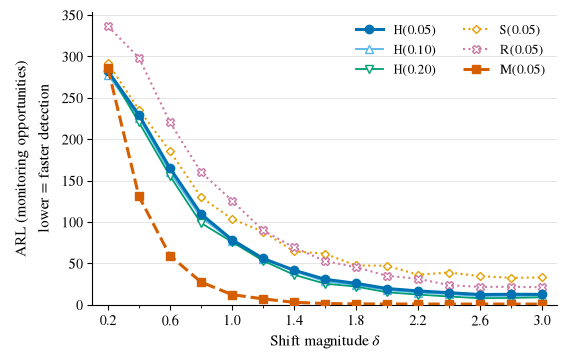

In [8]:
fig, ax = plt.subplots(figsize=(6.0, 3.8))
plot_schemes(ax, arl, CHART_ORDER)
ax.set_ylabel(ARL_LABEL)
ax.legend(ncol=2, loc="upper right")
save_figure(fig, "results_arl_all_schemes")
plt.show()

The ARL curves fall steeply between $\delta = 0.2$ and $\delta \approx 1.0$ and then flatten,
which is the expected shape: once the shift is large relative to the in-control spread of the
monitoring statistic, every scheme signals within a few monitoring opportunities and the
curves compress against a lower bound.

Because the ARL is a mean of a strongly right-skewed distribution, it is reported alongside
SDRL and MRL below.

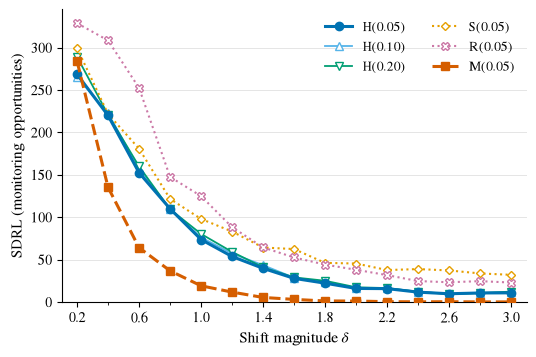

In [9]:
fig, ax = plt.subplots(figsize=(6.0, 3.8))
plot_schemes(ax, sdrl, CHART_ORDER)
ax.set_ylabel("SDRL (monitoring opportunities)")
ax.legend(ncol=2, loc="upper right")
save_figure(fig, "results_sdrl_all_schemes")
plt.show()

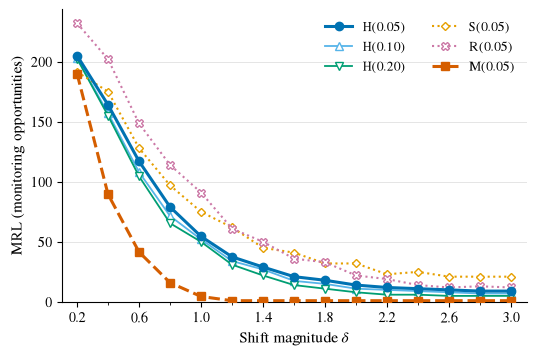

In [10]:
fig, ax = plt.subplots(figsize=(6.0, 3.8))
plot_schemes(ax, mrl, CHART_ORDER)
ax.set_ylabel("MRL (monitoring opportunities)")
ax.legend(ncol=2, loc="upper right")
save_figure(fig, "results_mrl_all_schemes")
plt.show()

The SDRL curves track the ARL curves closely, and at small shifts the SDRL is of the same
order as the ARL itself — the signature of a near-geometric run-length distribution. The MRL
lies well below the ARL at small shifts for every scheme, confirming the right skew.

## 4. Primary hybrid H(0.05) versus the conventional MEWMA benchmark M(0.05)

The pre-registered primary contrast compares the primary hybrid chart with the conventional
raw-data MEWMA applied to the same process. The committed artifact records the paired mean
difference and its paired standard error at each shift magnitude.

In [11]:
for key in ("primary_contrast_definition", "primary_contrast_direction"):
    print(f"{key}: {interpretation[key]}")

primary_contrast_definition: RL_H - RL_M
primary_contrast_direction: negative mean_difference means H(0.05) signals faster than M(0.05)


In [12]:
contrast = pd.DataFrame(primary_contrast).set_index("delta")
contrast_table = pd.DataFrame(
    {
        "H(0.05) ARL": arl["H(0.05)"],
        "M(0.05) ARL": arl["M(0.05)"],
        "mean difference H - M": contrast["mean_difference"],
        "paired SE": contrast["se_paired"],
    }
)
contrast_table["|difference| / SE"] = (
    contrast_table["mean difference H - M"].abs() / contrast_table["paired SE"]
)
contrast_table.round(3)

,H(0.05) ARL,M(0.05) ARL,mean difference H - M,paired SE,|difference| / SE
delta,,,,,
0.2,282.422,285.592,-3.170,15.936,0.199
0.4,229.358,131.110,98.248,9.703,10.125
0.6,165.254,59.646,105.608,6.708,15.743
0.8,109.980,27.672,82.308,4.795,17.167
1.0,78.806,12.406,66.400,3.202,20.739
1.2,56.128,7.338,48.790,2.324,20.994
1.4,41.972,3.106,38.866,1.731,22.449
1.6,30.936,1.686,29.250,1.217,24.041
1.8,26.066,1.214,24.852,0.979,25.382


The two primary schemes on their own, first over the full shift grid and then at the five
smallest simulated shifts only:

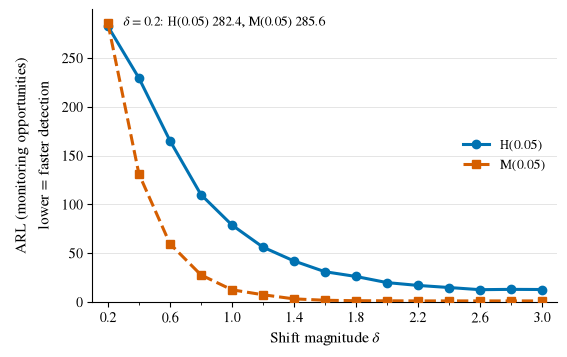

In [13]:
fig, ax = plt.subplots(figsize=(6.0, 3.8))
plot_schemes(ax, arl, PRIMARY)
h_small, m_small = arl.loc[deltas[0], PRIMARY]
ax.text(
    deltas[0] + 0.1,
    max(h_small, m_small),
    rf"$\delta = {deltas[0]}$: H(0.05) {h_small:.1f}, M(0.05) {m_small:.1f}",
    va="center",
    fontsize=9.5,
)
ax.set_ylabel(ARL_LABEL)
ax.legend(loc="center right")
save_figure(fig, "results_primary_hybrid_vs_classical_arl")
plt.show()

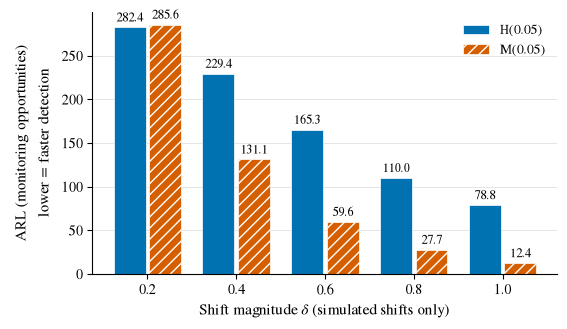

In [14]:
small_shifts = arl.loc[arl.index <= 1.0, PRIMARY]
positions = np.arange(len(small_shifts))
width = 0.36

fig, ax = plt.subplots(figsize=(6.0, 3.4))
for offset, chart in zip((-0.2, 0.2), PRIMARY):
    bars = ax.bar(
        positions + offset,
        small_shifts[chart],
        width,
        label=chart,
        color=SCHEME_STYLE[chart]["color"],
        hatch=HATCH.get(chart),
        edgecolor="white",
        linewidth=0.5,
    )
    ax.bar_label(bars, fmt="%.1f", padding=2, fontsize=9)
ax.set_xticks(positions, [f"{delta:.1f}" for delta in small_shifts.index])
ax.set_xlabel(r"Shift magnitude $\delta$ (simulated shifts only)")
ax.set_ylabel(ARL_LABEL)
ax.legend(loc="upper right")
save_figure(fig, "results_primary_small_shift_zoom")
plt.show()

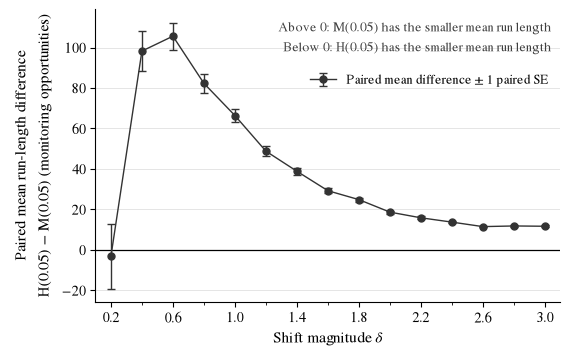

In [15]:
fig, ax = plt.subplots(figsize=(6.0, 3.8))
ax.axhline(0.0, color="black", linewidth=0.9)
ax.errorbar(
    contrast.index,
    contrast["mean_difference"],
    yerr=contrast["se_paired"],
    color=NEUTRAL,
    marker="o",
    markersize=5,
    linewidth=1.0,
    capsize=3,
    label="Paired mean difference ± 1 paired SE",
)
ax.text(
    0.98, 0.97,
    "Above 0: M(0.05) has the smaller mean run length\n"
    "Below 0: H(0.05) has the smaller mean run length",
    transform=ax.transAxes, ha="right", va="top", fontsize=9.5, color="0.25",
)
format_shift_axis(ax)
ax.set_ylabel("Paired mean run-length difference\nH(0.05) − M(0.05) (monitoring opportunities)")
ax.legend(loc="upper right", bbox_to_anchor=(1.0, 0.82))
save_figure(fig, "results_primary_paired_difference")
plt.show()

The error bars show one paired standard error and are not a hypothesis test; the committed
results contain no inferential procedure, so no claim of statistical significance is made
here.

At $\delta = 0.2$ the paired mean difference is small relative to its paired standard error,
so the two schemes are not distinguishable at the smallest shift on this evidence. From
$\delta = 0.4$ onwards the difference is positive and large relative to its standard error:
under the sign convention above, a positive difference means the conventional MEWMA signals
sooner than the hybrid chart. This is recorded as it stands.

The frozen experiment attaches the following qualification to the run-length definition:

In [16]:
print(interpretation["qualification"])

The sustained latent mean shift begins at tau=1, the first retained observation. Therefore x_1 through x_31 used before the first permitted monitoring decision are already post-change; the first monitoring opportunity is j=1 at original time t=32.


A compact summary of the complete run-length behaviour of the two primary schemes, with the
three statistics on a common shift axis:

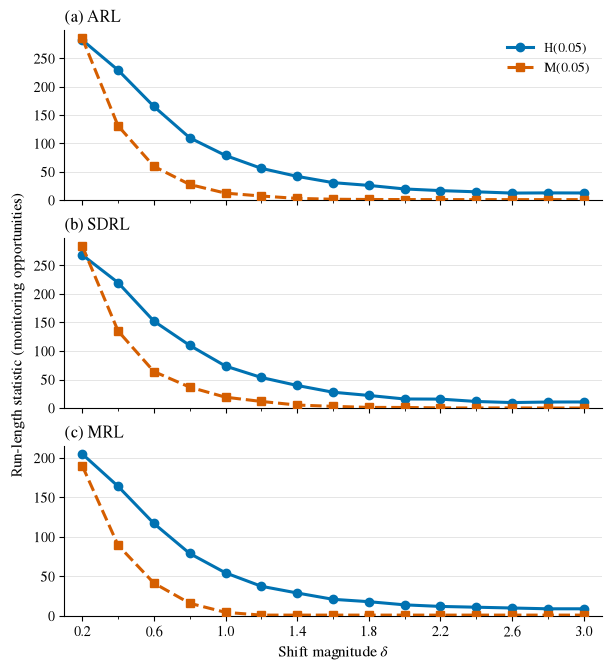

In [17]:
fig, axes = plt.subplots(3, 1, figsize=(6.0, 6.6), sharex=True, layout="constrained")
for ax, title, table in zip(axes, ["(a) ARL", "(b) SDRL", "(c) MRL"], [arl, sdrl, mrl]):
    plot_schemes(ax, table, PRIMARY)
    ax.set_title(title, loc="left")
    ax.label_outer()
axes[0].legend(loc="upper right")
fig.supylabel("Run-length statistic (monitoring opportunities)", fontsize=11)
save_figure(fig, "results_primary_run_length_metrics")
plt.show()

## 5. Hybrid versus its component ablations

The two ablations isolate the individual information sources that the hybrid monitoring
vector combines. S(0.05) monitors the OC-SVM anomaly score alone, R(0.05) monitors the log
reconstruction error alone, and H(0.05) monitors both jointly through the two-dimensional
MEWMA. Comparing the three therefore tests whether combining the two machine-learning
signals detects the fault faster than either signal used on its own — the question the hybrid
architecture exists to answer.

In [18]:
ablation = arl[["H(0.05)", "S(0.05)", "R(0.05)"]]
ablation.round(2)

chart,H(0.05),S(0.05),R(0.05)
delta,,,
0.2,282.42,292.09,336.57
0.4,229.36,235.73,298.41
0.6,165.25,185.82,220.65
0.8,109.98,130.38,160.47
1.0,78.81,103.85,126.07
1.2,56.13,88.60,90.07
1.4,41.97,64.69,69.39
1.6,30.94,61.82,53.01
1.8,26.07,47.67,45.58


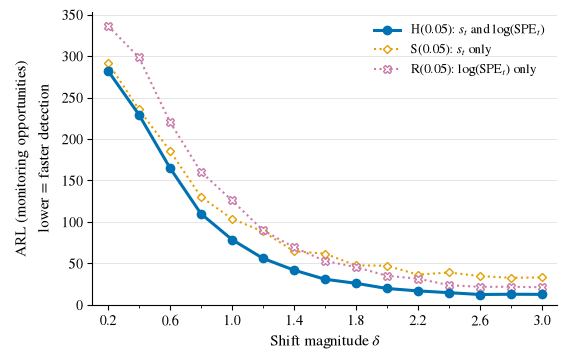

In [19]:
fig, ax = plt.subplots(figsize=(6.0, 3.8))
plot_schemes(ax, ablation, ["H(0.05)", "S(0.05)", "R(0.05)"], labels={
    "H(0.05)": r"H(0.05): $s_t$ and $\log(\mathrm{SPE}_t)$",
    "S(0.05)": r"S(0.05): $s_t$ only",
    "R(0.05)": r"R(0.05): $\log(\mathrm{SPE}_t)$ only",
})
ax.set_ylabel(ARL_LABEL)
ax.legend(loc="upper right")
save_figure(fig, "results_hybrid_ablation_arl")
plt.show()

In [20]:
# Verify, rather than assume, the direction of the hybrid-versus-ablation comparison.
beats_both = (ablation["H(0.05)"] < ablation["S(0.05)"]) & (
    ablation["H(0.05)"] < ablation["R(0.05)"]
)
large_shifts = ablation.index >= 0.4

print(f"H(0.05) ARL below both S(0.05) and R(0.05) for every delta >= 0.4: "
      f"{bool(beats_both[large_shifts].all())}")
print(f"Shift magnitudes where H(0.05) does not have the lowest ARL of the three: "
      f"{list(ablation.index[~beats_both])}")

H(0.05) ARL below both S(0.05) and R(0.05) for every delta >= 0.4: True
Shift magnitudes where H(0.05) does not have the lowest ARL of the three: []


The hybrid chart has a lower ARL than both of its one-component ablations at every shift
magnitude on the grid. The margin is small at $\delta \le 0.4$ (at $\delta = 0.4$, 229.4 for
H(0.05) against 235.7 for S(0.05)) and clear from $\delta = 0.6$ upwards. Combining
the OC-SVM score and the reconstruction error into a single two-dimensional monitoring vector
therefore adds detection value relative to either component alone. Of the two ablations,
S(0.05) is the stronger one on this fault, but neither matches the joint chart.

## 6. Sensitivity to the smoothing constant $\lambda$

The three hybrid charts differ only in the MEWMA smoothing constant. A larger $\lambda$ gives
more weight to the most recent monitoring vector and discounts the past more quickly; a
smaller $\lambda$ retains more memory of earlier observations. Each value was calibrated
separately on D3 to the same $\mathrm{ARL}_0$ target, so the comparison below is between
schemes matched on nominal in-control performance.

In [21]:
lambda_table = arl[["H(0.05)", "H(0.10)", "H(0.20)"]]
lambda_table.round(2)

chart,H(0.05),H(0.10),H(0.20)
delta,,,
0.2,282.42,278.08,283.55
0.4,229.36,226.27,220.47
0.6,165.25,160.53,155.82
0.8,109.98,105.84,98.97
1.0,78.81,77.71,76.16
1.2,56.13,55.77,53.46
1.4,41.97,40.77,36.44
1.6,30.94,28.42,25.63
1.8,26.07,24.10,22.17


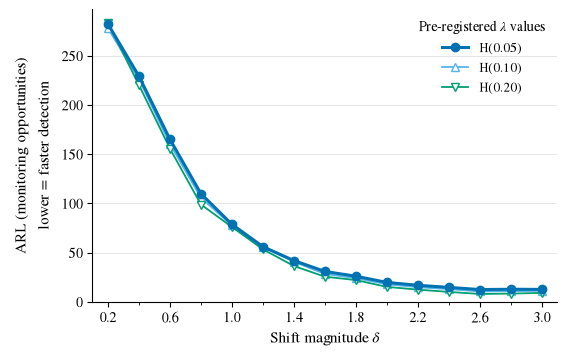

In [22]:
fig, ax = plt.subplots(figsize=(6.0, 3.8))
plot_schemes(ax, lambda_table, ["H(0.05)", "H(0.10)", "H(0.20)"])
ax.set_ylabel(ARL_LABEL)
ax.legend(loc="upper right", title=r"Pre-registered $\lambda$ values")
save_figure(fig, "results_lambda_sensitivity_arl")
plt.show()

The three hybrid variants behave similarly across the shift grid, with the differences
between them much smaller than the difference between the hybrid family and its ablations.
The three $\lambda$ values were pre-registered as a sensitivity analysis rather than as a
search, so no optimal $\lambda$ is claimed; the result reported here is that the hybrid
chart's out-of-control behaviour is not sensitive to $\lambda$ over this range.

## 7. Run-length distributions

The ARL is a single summary of a skewed distribution, and two schemes with similar ARLs can
behave quite differently in practice. The individual run lengths behind the summaries above
are inspected here for H(0.05) and M(0.05) at three representative shift magnitudes.

In [23]:
REPRESENTATIVE_DELTAS = [0.2, 1.0, 3.0]


def delta_key(delta):
    return "delta_" + f"{delta:.1f}".replace(".", "p")


def d5_run_lengths(chart_key, delta):
    return run_lengths[f"d5/{chart_key}/{delta_key(delta)}/run_lengths"]


distribution_summary = pd.DataFrame(
    [
        {
            "chart": chart,
            "delta": delta,
            "n": rl.size,
            "mean (ARL)": rl.mean(),
            "SD (SDRL)": rl.std(ddof=1),
            "median (MRL)": np.median(rl),
            "Q1": np.quantile(rl, 0.25),
            "Q3": np.quantile(rl, 0.75),
            "max": rl.max(),
        }
        for chart, chart_key in [("H(0.05)", "H_0p05"), ("M(0.05)", "M_0p05")]
        for delta in REPRESENTATIVE_DELTAS
        for rl in [d5_run_lengths(chart_key, delta)]
    ]
).set_index(["delta", "chart"]).sort_index()

distribution_summary.round(2)

n  mean (ARL)  SD (SDRL)  median (MRL)    Q1     Q3   max
delta chart                                                               
0.2   H(0.05)  500      282.42     268.45         205.0  85.0  384.5  2010
      M(0.05)  500      285.59     283.88         190.0  77.0  384.0  1603
1.0   H(0.05)  500       78.81      73.56          54.5  24.0  112.0   422
      M(0.05)  500       12.41      19.01           4.5   1.0   17.0   133
3.0   H(0.05)  500       12.70      10.68           9.0   6.0   15.0    89
      M(0.05)  500        1.00       0.00           1.0   1.0    1.0     1

The empirical cumulative distribution function (ECDF) of the raw committed run lengths shows,
for every $r$, the proportion $P(\mathrm{RL} \le r)$ of the 500 replications that had signalled
by run length $r$. No distribution is fitted.

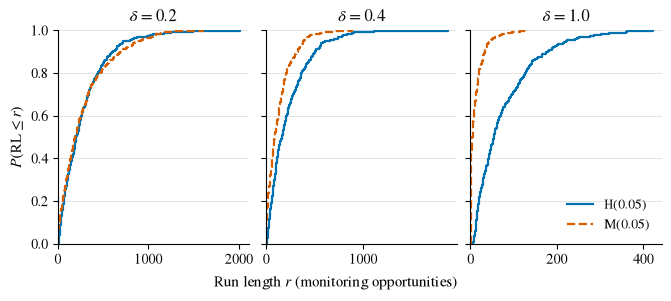

In [24]:
PRIMARY_KEYS = {"H(0.05)": "H_0p05", "M(0.05)": "M_0p05"}

fig, axes = plt.subplots(1, 3, figsize=(6.6, 2.9), sharey=True, layout="constrained")
for ax, delta in zip(axes, [0.2, 0.4, 1.0]):
    for chart, chart_key in PRIMARY_KEYS.items():
        style = SCHEME_STYLE[chart]
        ax.ecdf(d5_run_lengths(chart_key, delta), label=chart, color=style["color"],
                linestyle=style["linestyle"], linewidth=1.6)
    ax.set_title(rf"$\delta = {delta}$")
    ax.set_xlim(left=0)
    ax.locator_params(axis="x", nbins=3)
axes[0].set_ylabel(r"$P(\mathrm{RL} \leq r)$")
axes[-1].legend(loc="lower right")
fig.supxlabel("Run length $r$ (monitoring opportunities)", fontsize=11)
save_figure(fig, "results_primary_run_length_ecdf")
plt.show()

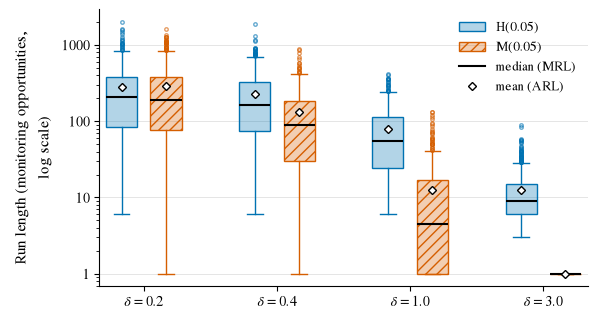

In [25]:
box_deltas = [0.2, 0.4, 1.0, 3.0]
fig, ax = plt.subplots(figsize=(6.3, 3.6))
for i, delta in enumerate(box_deltas):
    for j, (chart, chart_key) in enumerate(PRIMARY_KEYS.items()):
        colour = SCHEME_STYLE[chart]["color"]
        ax.boxplot(
            d5_run_lengths(chart_key, delta),
            positions=[3 * i + j],
            widths=0.7,
            patch_artist=True,
            showmeans=True,
            boxprops=dict(facecolor=to_rgba(colour, 0.3), edgecolor=colour, hatch=HATCH.get(chart)),
            whiskerprops=dict(color=colour),
            capprops=dict(color=colour),
            medianprops=dict(color="black", linewidth=1.5),
            meanprops=dict(marker="D", markerfacecolor="white", markeredgecolor="black", markersize=4),
            flierprops=dict(marker="o", markersize=2.5, markerfacecolor="none",
                            markeredgecolor=colour, alpha=0.6),
        )
ax.set_xticks([3 * i + 0.5 for i in range(len(box_deltas))],
              [rf"$\delta = {delta}$" for delta in box_deltas])
ax.set_yscale("log")
ax.yaxis.set_major_formatter("{x:g}")
ax.set_ylabel("Run length (monitoring opportunities,\nlog scale)")
ax.legend(
    handles=[
        *(Patch(facecolor=to_rgba(SCHEME_STYLE[c]["color"], 0.3), edgecolor=SCHEME_STYLE[c]["color"],
                hatch=HATCH.get(c), label=c) for c in PRIMARY_KEYS),
        Line2D([], [], color="black", linewidth=1.5, label="median (MRL)"),
        Line2D([], [], marker="D", linestyle="none", markerfacecolor="white",
               markeredgecolor="black", markersize=4, label="mean (ARL)"),
    ],
    loc="upper right",
)
save_figure(fig, "results_primary_run_length_boxplots")
plt.show()

At $\delta = 0.2$ the two schemes have almost the same ARL, but both distributions are heavily
right-skewed: the median sits well below the mean and the upper tail extends by an order of
magnitude, so a single realisation of either chart can take far longer to signal than the ARL
suggests. At large shifts the two distributions differ in kind rather than in degree — at
$\delta = 3.0$ every M(0.05) replication signals at the first monitoring opportunity, while
H(0.05) retains a right tail with a median of 9 and a maximum of 89. Reporting only the ARL
would hide both features, which is why SDRL and MRL are reported alongside it throughout.

The ECDFs compare the two schemes at every run length rather than through a few summaries.
At $\delta = 0.2$ the two curves nearly coincide. At $\delta = 0.4$ and $\delta = 1.0$ the
M(0.05) curve lies at or above the H(0.05) curve at every run length, so a larger share of
M(0.05) replications has signalled by any given $r$.

## 8. Main findings

**In-control validation.** Applying the six frozen charts to the independent in-control bank
D4 gives in-control run lengths broadly in line with the design target. The empirical D4
$\mathrm{ARL}_0$ values range from 315 to 404 against a target of 370 (within about 15%), with
no censored run lengths and deviations between about 0.4 and 4 standard errors; the three
hybrid charts run below target, most noticeably H(0.20), and M(0.05) above it. The Phase I
calibration therefore broadly carries over to in-control data it was not fitted on, and the
out-of-control comparisons are read alongside each chart's realised D4 $\mathrm{ARL}_0$.

**The hybrid combination adds value over its components.** At every tested shift
magnitude, the primary hybrid chart H(0.05) has a lower ARL than both of its one-component
ablations, S(0.05) and R(0.05); the margin is small at $\delta \le 0.4$ and clear from
$\delta = 0.6$ upwards. Monitoring the OC-SVM anomaly score and the
reconstruction error jointly is better than monitoring either alone, which is the specific
claim the hybrid monitoring vector was designed to test.

**The conventional benchmark detects this fault faster.** The conventional raw-data MEWMA
M(0.05) has a lower ARL than H(0.05) across $\delta \geq 0.4$, and the paired mean run-length
difference is positive and large relative to its paired standard error over that range. At
$\delta = 0.2$ the paired difference is small relative to its paired standard error and the
two schemes are not distinguishable on this evidence; no significance test accompanies the
committed results, so no inferential claim is made in either direction.

**Sensitivity.** The three pre-registered $\lambda$ values produce similar hybrid performance
across the shift grid, so the conclusions above are not an artefact of a particular smoothing
constant.

**Interpretation.** The experiment demonstrates that the hybrid CAE + OC-SVM + MEWMA
architecture is a valid monitoring scheme — it calibrates correctly, validates on independent
in-control data, and extracts real detection value from combining its two learned signals —
but that it does not outperform the conventional MEWMA benchmark under this particular
simulated process and frozen design. That is a finding about this simulation, this fault
mechanism and this design. The simulated process is low-dimensional and the fault enters as a
sustained mean shift in the latent state, which is precisely the setting a conventional
multivariate MEWMA on the raw observations is built for; the result should not be read as a
general statement about learned-representation monitoring, which is motivated by
higher-dimensional or non-linear settings that this design does not represent.

## 9. Reproduction note

Every table and figure in this notebook is derived from the committed Phase II result
artifacts `results/d4_validation_summary.json`, `results/d5_performance_summary.json`,
`results/run_lengths.npz` and the frozen control limits in `models/control_limits.json`.
The thesis figures are written to `figures/` by `save_figure` in `thesis_plots.py`;
re-running this notebook regenerates them from the same artifacts.

No data is generated, no model is fitted or loaded for inference, no control limit is
recalibrated and no Monte Carlo simulation is executed here. Reproducing the analysis below
requires only the committed artifacts; reproducing the artifacts themselves is the job of
`reproduce_all.py`.